# RoPeR Low-frequency processing Implementation for Rodriguez 2026

This notebook shows a full implementation of the methods used in Rodriguez 2026 to process the low frequency rover penetrating radar (RoPeR) data from the Tianwen 12 mission. The only requirement to run is to have downloaded the .2CL files and associated metadata files. As I'm writing this they don't appear to be available -- if this is still the case reach out and I can send a zip whith however much of the data you'd like. The processing pipeline is as follows:

1. Import in-house and other packages
2. Retrieve all files and concatonate the data to form a radargram
   - Consider the GPR trigger type
     
3. View the raw data
   - Phase correction for 2.5ns sampling interval
   - Remove self-detection traces (we'll use these later)
4. Simple background removal: RoPeR library supports other methods if you want to use window mean or eigen background removal (Al-Nuaimy 2010)!
5. Amplitude interpolation
6. Lateral energy equalization
7. Bandpass filter (doesn't actually do much more of a formalism)
8. Exponential gain

9. Velocity modeling
10. Migration
11. Elevation Correction

These last three are done in /determining_velocity_model and /RoPeR_migration!

# 1. Import our in-house package and dependencies
Should install relevant dependencies if there is a conflict

In [6]:
import RoPeR
from RoPeR import bandpass, bgr, energy_eq, gain, prestitch
import SimulatingGPR.gprsim as gprsim

In [7]:
import os
from tqdm import tqdm
from pds4_tools.reader.core import pds4_read
import numpy as np
import matplotlib.pyplot as plt

# 2. Load the RoPeR data from a folder on our computer which contains the data files

In [8]:
'''
Retrieving files and sorting them
'''
n, m = 0, 109 # 0-109, load all 109 files
data_dir = '/Users/coltenrodriguez/Desktop/Senior_Thesis/RoPeR_LF' # were data

In [9]:
files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if '.2CL' in f]
files = sorted(files, key=lambda f: int(f[-10:-6]))[n:m]
length = len(files)

sample_depth = {6000:15000, 4000:10000, 2000:5000, 1000:2500} # number of total pixels in either R/I data: nanoseconds penetration
observable_depth_ns = 1200 # Arbitaraty value

In [10]:
from collections import Counter, defaultdict
'''
Check inhomogenous data (e.g. not all files are LF). also get the effective data legnth (to get ns/px)
'''

effective_data_lens = [info[8] for info in [pds4_read(file, quiet=True)[0].data[0] for file in files]] # Just take the metadata associated with the first trace, as each trace in each file will be the same


if len(set(effective_data_lens)) == 1:
    print(f"Input data is homogenous. Effective data length is {effective_data_lens[0]} bytes. \n {effective_data_lens[0]/8} fpn for real data -- {(effective_data_lens[0]/8)/sample_depth[effective_data_lens[0]/8]} px/ns")
    half_length = int(effective_data_lens[0]/8)
    px_per_ns = half_length/sample_depth[effective_data_lens[0]/8]
else:
    print("Inhomogenous data types. Check that all files are LF or have the same effective data length")

Input data is homogenous. Effective data length is 48000 bytes. 
 6000.0 fpn for real data -- 0.4 px/ns


In [11]:
remove_air = 0

In [12]:
'''
Stitching multiple data files together and gathering some preprocessing data for each file
'''
phase = [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pixel_distances = []
sample_meta = None
for f, i, j in zip(files, range(0, length), tqdm(range(length-1))): 
    if n<=i<=m:
        fdata = pds4_read(f, quiet=True)[0].data
        if len(set([int.from_bytes(d[6], 'big', signed=False) for d in fdata])) > 1:
            raise Exception("Trigger mode is not homogenously fixed_distance")
        sample_meta = fdata[0] # might be useless
        scan2d = np.array([d[9] for d in fdata])
        real_part_scan2d = np.array(scan2d[:, :half_length]).T[remove_air:, :]
        
        sample_depth_px, real_part_scan2d_depth_adj = prestitch.depth_correction(real_part_scan2d, px_per_ns, observable_depth_ns)
        real_part_scan2d_depth_self_adj, sds = prestitch.remove_self_detection(real_part_scan2d_depth_adj)
        sds = prestitch.phase_correction(sds, phase[i])
        real_part_scan2d_depth_self_phase_adj = prestitch.phase_correction(real_part_scan2d_depth_self_adj, phase[i])
        real_part_scan2d_depth_self_phase_bgr_adj, _ = bgr.remove_bg(real_part_scan2d_depth_self_phase_adj)
        # Assume this is all interpreted
        yaw = np.array([d[23] for d in fdata])
        pos_x = np.array([d[19] for d in fdata])
        pos_y = np.array([d[20] for d in fdata])
        pos_z = np.array([d[21] for d in fdata])
        pixel_distances.append(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
        if i == n:
            raw = real_part_scan2d_depth_adj
            self_detection = real_part_scan2d_depth_self_adj
            phase_offset = real_part_scan2d_depth_self_phase_adj
            phase_offset_bg = real_part_scan2d_depth_self_phase_bgr_adj
            self_detections = np.array(sds)
            yaws = yaw
            poss_x, poss_y, poss_z = pos_x, pos_y, pos_z
            trace_dist_m = np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3) # Fixed dist trigger is not fixed for all scans, record dist in a way that pulls from the .CL
        else:
            raw = np.concatenate((raw, real_part_scan2d_depth_adj), axis=1)
            self_detection = np.concatenate((self_detection, real_part_scan2d_depth_self_adj), axis=1)
            phase_offset = np.concatenate((phase_offset, real_part_scan2d_depth_self_phase_adj), axis=1)
            phase_offset_bg = np.concatenate((phase_offset_bg, real_part_scan2d_depth_self_phase_bgr_adj), axis=1)
            self_detections = np.concatenate((self_detections, sds), axis=1)
            yaws = np.concatenate((yaws, yaw))
            poss_x, poss_y, poss_z = np.concatenate((poss_x, pos_x)), np.concatenate((poss_y, pos_y)), np.concatenate((poss_z, pos_z))
            trace_dist_m+=np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
            

100%|███████████████████████████████████████████████████████████████| 107/107 [00:14<00:00,  7.40it/s]


## 2.1 Now we have all the data: But one problem?
Its up to us to manipulate it so that it is satisfactory. First, we want homogenous dx and dt. Right now dt is easy, given by 1/px_per_ns -- we'd know somethings up with this if the check for inhomogenous data failed (it shouldn't have). Dx is a little more complicated as the fixed distance trigger for the LF data switches to dx = 0.25 right before 2000 pixels. See:

Boundary pixel where dx starts being 0.25 is 1739


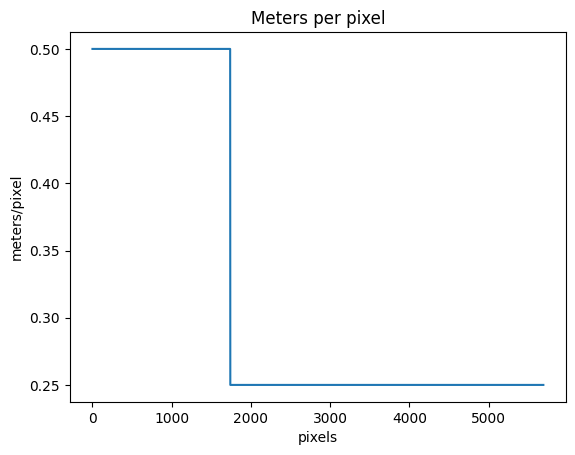

In [17]:
plt.plot(np.concatenate(pixel_distances).ravel())
plt.title("Meters per pixel")
plt.xlabel("pixels")
plt.ylabel("meters/pixel")
print('Boundary pixel where dx starts being 0.25 is', [i for i, val in enumerate(np.concatenate(pixel_distances).ravel()) if val==0.25][0])

### We have a couple options for dealing with this
1. Use cv2.resize: This would be visually appealing, yes, but I'm veto-ing it becasue we cant just create artificual data.
2. Give myself a migrane adjusting all of the velocity modeling code to use the pixel distrances array in all calculations: essentially treat dx as variable: doable, but overkill. Something simple is ideal here.
3. **Split the raw B-scan in two and just do everything past pre-processing separately**, then after imaging splice the tow back together. Fewer headaches, just hope there are no hyperbolae on the boundary. Eh, we should have enough as is. This solution doesn't create data for leave any out. Sure there may be a visible boundary in the final image, but I'll take this over disingenuous cv2.resize any day

# 3 Take a look at this initial data

## 3.1 Load a couple functions that make manipulating the data easier

**meters_to_pixels**: 
    
    takes a range along the horizontal and transforms it into pixel indices. this is useful as the RoPeR fixed distance trigger has multiple fixed distances under which it operates, for LF, this switches from 1 recording every 0.5m to everyu 0.25m

**norm2d**:

    Normalizes a 2d array to 0-1

**zoom**:

    Takes a slice of the full data. Useful for hyperbola tracing in velocity modeling, to check data quality, or to simply zoom in on features of the data



In [9]:
def meters_to_pixels(meter_interval, pixel_distances):
    start_m, end_m = meter_interval

    # cumulative distance to the start of each pixel
    cumulative_m = np.concatenate(([0], np.cumsum(pixel_distances)))

    # find pixel indices
    start_pixel = np.searchsorted(cumulative_m, start_m, side="left")
    end_pixel = np.searchsorted(cumulative_m, end_m, side="right") - 1

    # clamp to valid range
    start_pixel = max(0, min(start_pixel, len(pixel_distances) - 1))
    print('hi')
    end_pixel = max(0, min(end_pixel, len(pixel_distances) - 1))

    return start_pixel, end_pixel
    
def norm2d(array):
    min_val = np.min(array)
    max_val = np.max(array)
    
    # Apply the normalization formula
    normalized_array = 2 * ((array - min_val) / (max_val - min_val)) - 1
    
    return normalized_array

def zoom(array, bounds):
    # Bounds in [left, right, bottom, top]
    # [:, :], Col slice (vertical), rows slice (horiz), row slice should be left:right, byut col slice should be bottom:top
    '''
    Bounds should be specified as:

                Left: Left coordinate (in meters)
                Right: Right coord (in meters)
                Top: stratigraphic bottom, the larger twt (in ns)
                Bottom: stratigraphic top, the smaller twt (in ns)

    This way bounds may be passed as an arg to plt without modification to show true (phyiscal) position 
    '''
    left, right = meters_to_pixels((bounds[0], bounds[1]), np.concatenate(pixel_distances).ravel())
    return array[int(bounds[3]*px_per_ns):int(bounds[2]*px_per_ns), left:right], bounds
    

## 3.2 View the raw data input

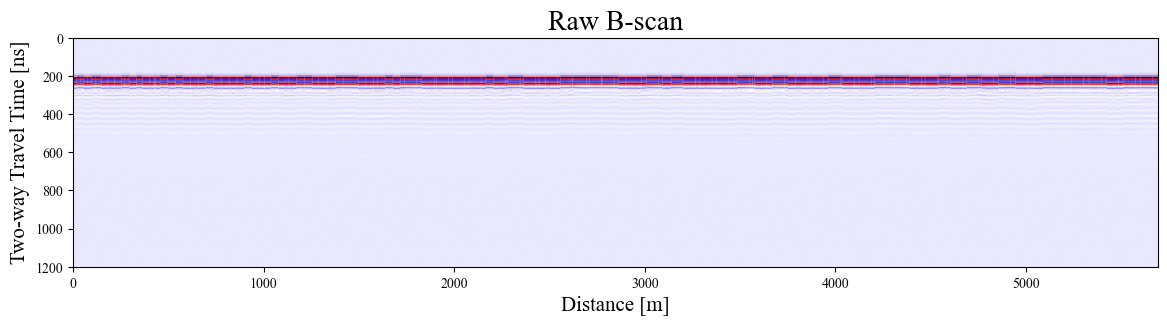

In [10]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 15,
    'axes.titlesize': 20,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.4,  # Example: Increase vertical spacing
    'figure.figsize': (14, 4) # Adjust figure size
})
rows, cols = raw.shape
plt.imshow(raw, cmap='seismic', extent = [0, cols, observable_depth_ns, 0])
plt.title("Raw B-scan")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/raw.png', raw, cmap='seismic')

## 3.3 Remove the self detection traces

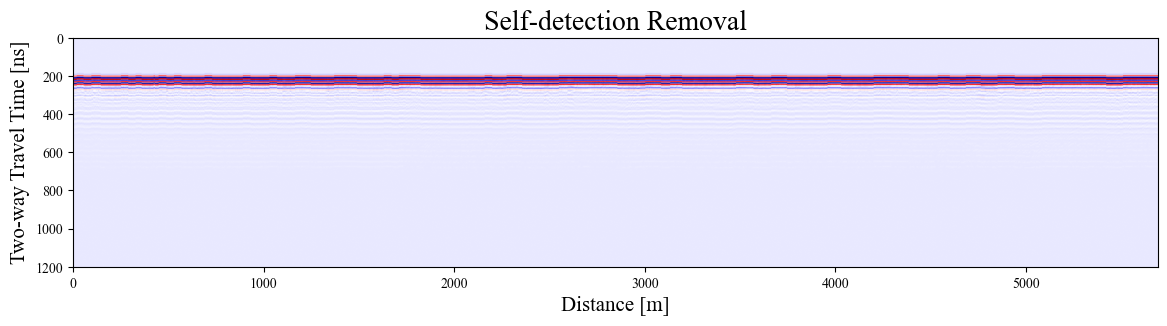

In [11]:
plt.imshow(self_detection, cmap='seismic',extent = [0, cols, observable_depth_ns, 0])
plt.title("Self-detection Removal")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/self_detection.png', self_detection, cmap='seismic')

## 3.4 Align the traces with the ground

27128466.0 -24998366.0


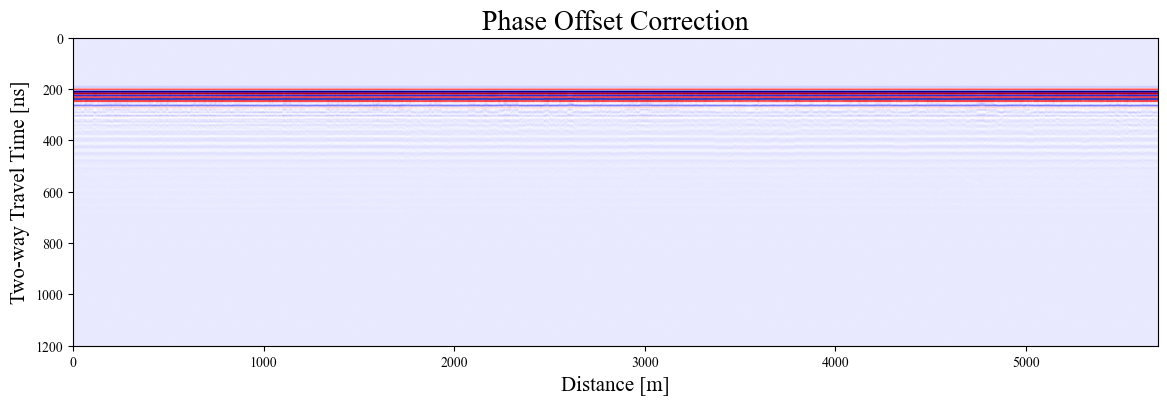

In [12]:
plt.imshow(phase_offset, cmap='seismic', aspect='auto', extent = [0, cols, observable_depth_ns, 0])
plt.title("Phase Offset Correction")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
print(np.amax(phase_offset), np.amin(phase_offset))
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/phase_offset.png', phase_offset, cmap='seismic')

# 4. Signal processing
I'll just go at this in the order it's explained in the text. It's important to remind myself that the point here is not to reveal things that arent there, it's to 'clean' the noise away to see best what the refections look like. Sure if we do bgr removal 1000 times or throw a super long pipeline at this data we'll start seeing some funky stuff. I'd like to keep this pre-migration processing as simple as possible within reason. Indeed this isnt all the steps previously taken for the HF data, but I think what's important is that I've not only explained what's going on in each of these steps in my paper, but exactly ****

## 4.1 Remove horizontal Banding

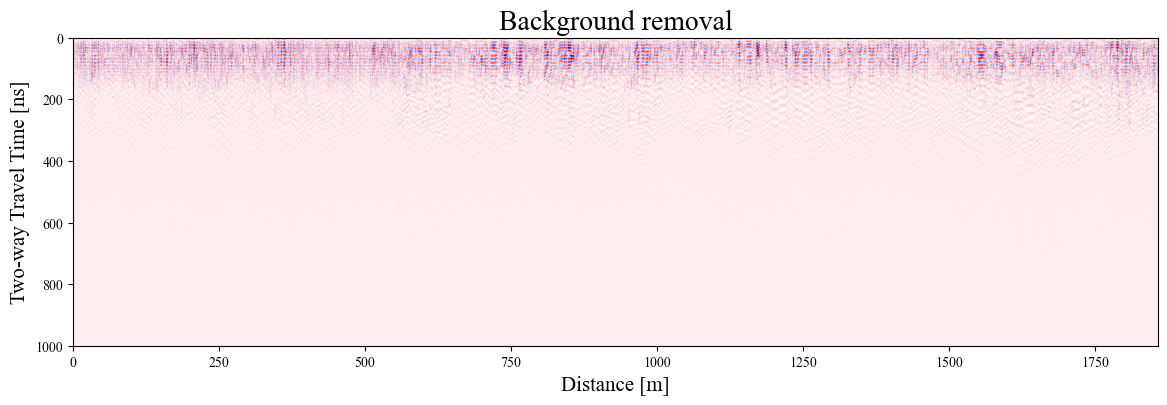

In [13]:
array = phase_offset_bg[int(200*px_per_ns):, :]# adjust time-lag
plt.imshow(array, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, (1/px_per_ns)*array.shape[0], 0])
plt.title("Background removal")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/bgr.png', array, cmap='seismic')

## 4.1.1 Personal Preference Fix: Trace-to-trace coupling due to uneven surface

In [14]:
# Striping is most apparent in the upper 200ns
import numpy as np
from scipy.ndimage import uniform_filter1d

def trace_balance_rms(D, tmin, tmax, smooth_traces, eps):
    nt, nx = D.shape
    if tmax is None:
        tmax = int(1 * nt)  # top 20% by default

    W = D[tmin:tmax, :]
    rms = np.sqrt(np.mean(W**2, axis=0) + eps)

    # smooth lateral gain curve
    rms_s = uniform_filter1d(rms, size=smooth_traces, mode='nearest')

    # scale each trace to match median energy
    target = np.median(rms_s)
    gain = target / (rms_s + eps)

    return D * gain[None, :], gain

array, gain = trace_balance_rms(array, tmin=0, tmax=None, smooth_traces=2, eps=100)


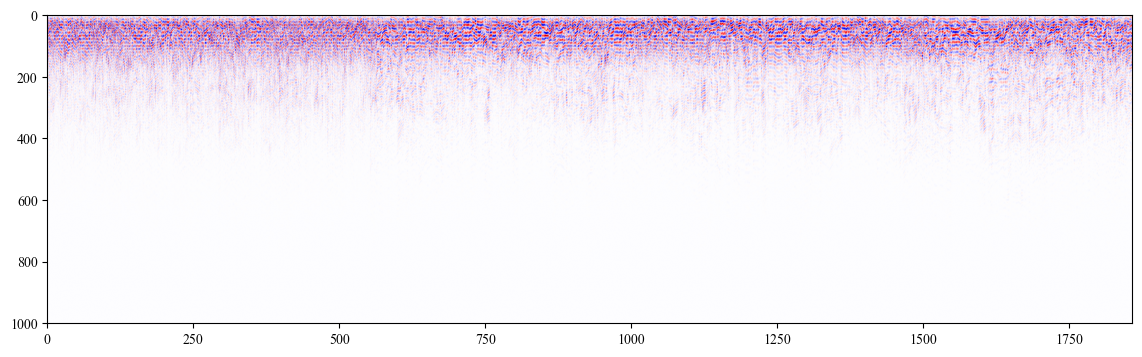

In [15]:
plt.imshow(array, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, (1/px_per_ns)*array.shape[0], 0])
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/destripe.png', array, cmap='seismic')

## 4.2 Lateral energy equalization

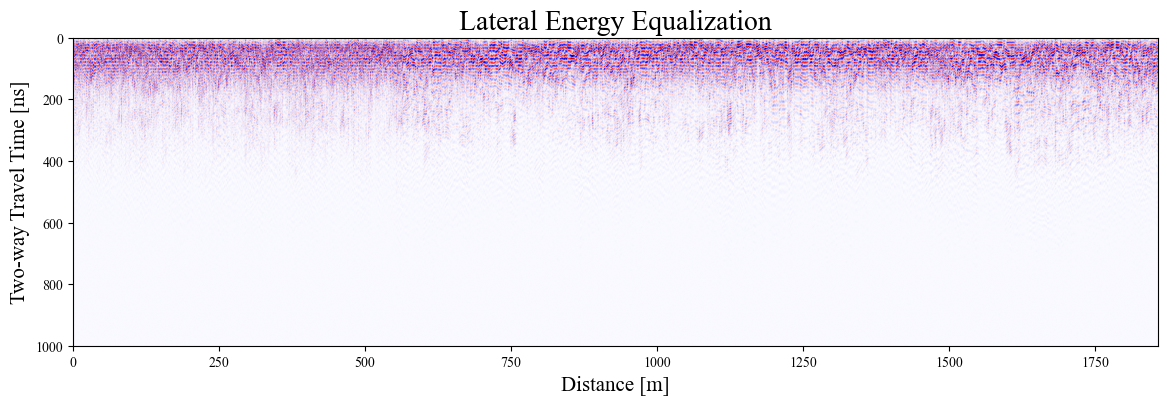

In [16]:
arr = energy_eq.lateral_energy_equalization(array, 10)
plt.imshow(arr, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, (1/px_per_ns)*arr.shape[0], 0])
plt.title("Lateral Energy Equalization")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/lee.png', arr, cmap='seismic')

## 4.3 Bandpass filter

3.4 shows that the signal is pretty consistent across the data, this step shouldn't do much, but it also shouldn't hurt


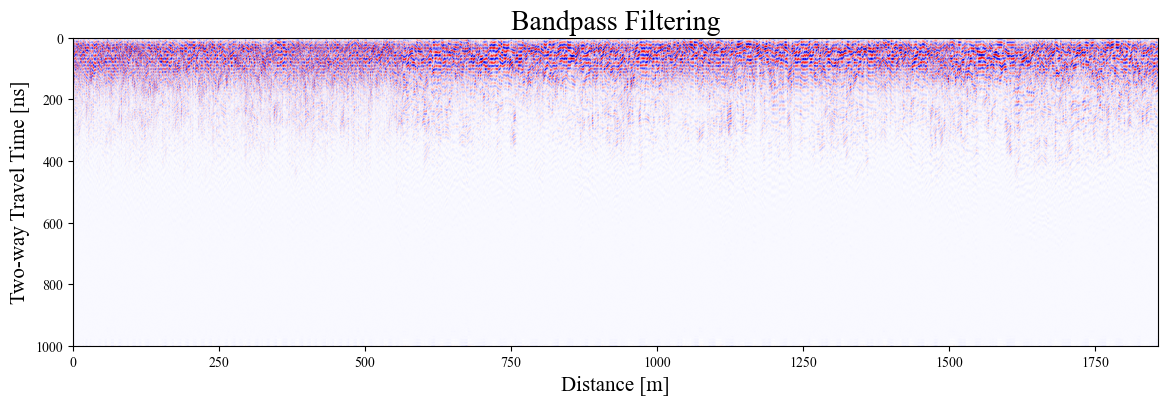

In [19]:
from scipy.fft import fft, ifft, fftfreq    
arr = np.array([bandpass.bandpass_filter(t, dt=((1/px_per_ns)*1e-9), low_f=1.5e7, high_f=9.5e7) for t in arr.T]).T
plt.imshow(arr, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, (1/px_per_ns)*arr.shape[0], 0])
plt.title("Bandpass Filtering")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/bandpass.png', arr, cmap='seismic')

## 4.4 Clip the air waves and gain the data

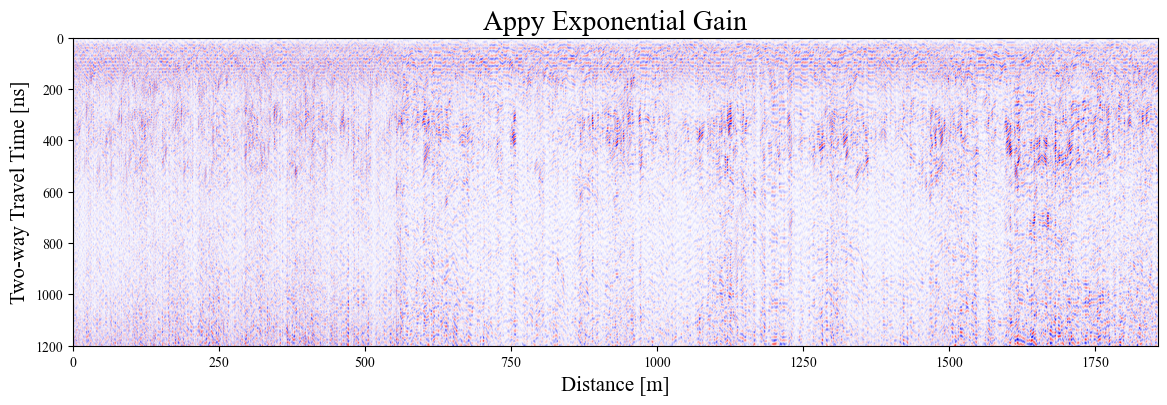

In [21]:
import RoPeR.gain as gain
p = gain.apply_gain(array, 0.019, gain_type='exponential', agc_window=30)
plt.imshow(p, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, observable_depth_ns, 0])
plt.title("Appy Exponential Gain")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/gained.png', p, cmap='seismic')

In [23]:
np.save('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/determining_a_velocity_model/preprocessed_data.npy', p)


In [22]:
os.getcwd()

'/Users/coltenrodriguez/Desktop/GPR-modeling'